# Libraries

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.kernel_ridge import KernelRidge # Not needed to proceed
from sklearn.svm import SVR # Not needed to proceed
from sklearn.preprocessing import StandardScaler # Not needed to proceed
from sklearn.cluster import KMeans # Not needed to proceed

# 1-Axis Visual 

In [16]:
real_df = pd.read_csv("palm_back_regular/2024-06-03_10-22-17/measurement.csv")
real_df = real_df.drop(1200, axis=0)
for col in real_df.columns:
    real_df[col] = pd.to_numeric(real_df[col])
real_df_x = pd.DataFrame(real_df["x"])

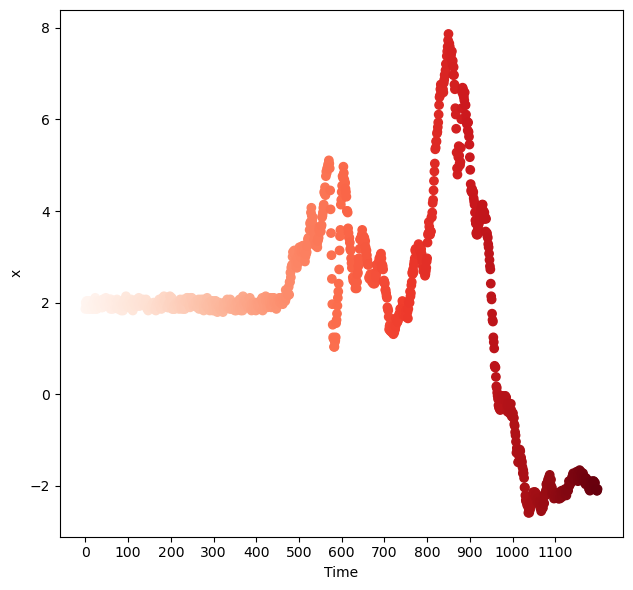

In [18]:
cmap = plt.get_cmap('Reds')
colors = cmap(np.linspace(0, 1, len(real_df_x)))

plt.figure(figsize=(18,6))
plt.subplot(1,3,1)

plt.scatter(real_df_x.index, real_df_x["x"], color=colors)

# Set the labels for the axes
plt.xlabel('Time')
plt.ylabel('x')

# Set the x-ticks with a line space of 1
plt.xticks(np.arange(real_df.index.min(), real_df.index.max() + 1, 100))
#plt.xticks([])

# Set the y-ticks with a line space of 5
#plt.yticks(np.arange(real_df_x.min(), real_df_x.max() + 1, 3))

# Display the plot
plt.tight_layout()
plt.show()


# Using Regression For Easy Clustering

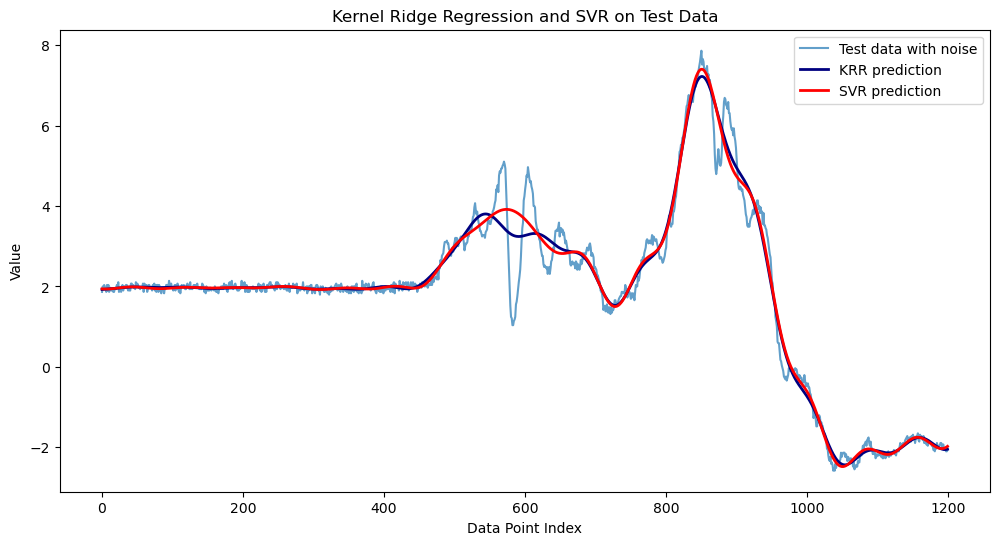

In [21]:
X = real_df_x.index.values.reshape(-1, 1)
y = real_df_x.values.ravel()

kr = KernelRidge(alpha=0.01, kernel='rbf', gamma=0.0002)
kr.fit(X, y)

y_pred = kr.predict(X)

svr = SVR(kernel='rbf', C=100, gamma=0.0002, epsilon=0.1)
svr.fit(X, y)

y_pred_kr = kr.predict(X)
y_pred_svr = svr.predict(X)

plt.figure(figsize=(12, 6))
plt.plot(X, y, label='Test data with noise', alpha=0.7)
plt.plot(X, y_pred_kr, color='navy', lw=2, label='KRR prediction')
plt.plot(X, y_pred_svr, color='red', lw=2, label='SVR prediction')
plt.xlabel('Data Point Index')
plt.ylabel('Value')
plt.legend()
plt.title('Kernel Ridge Regression and SVR on Test Data')
plt.show()

# Finding Action with Clustering (Will not be used)

C:\Users\birke\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\birke\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


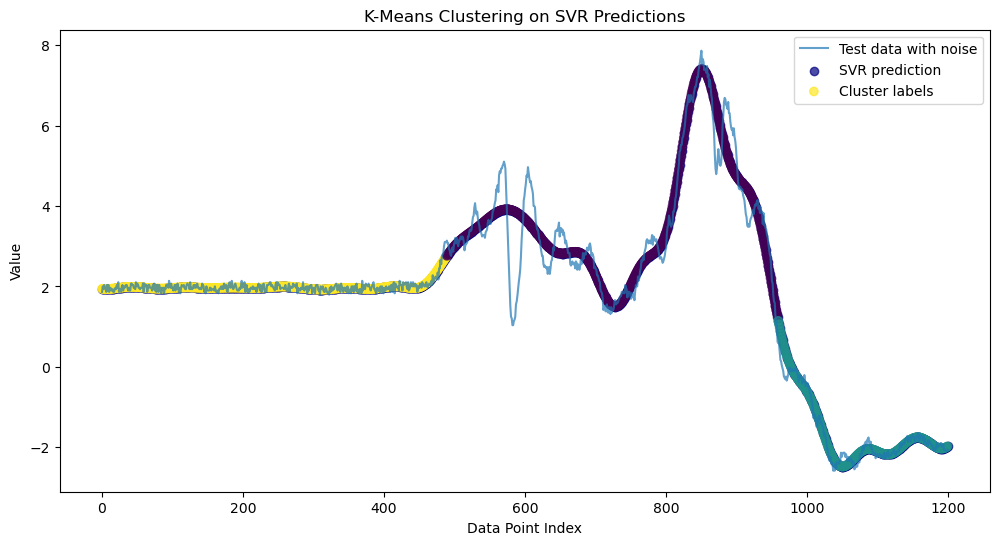

In [24]:
# Prepare the dataset for clustering
clustering_df = pd.DataFrame({
    'index': X.flatten(),
    'svr_pred': y_pred_svr
})

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(clustering_df)

# Apply K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(X_scaled)
labels = kmeans.labels_

# Add cluster labels to the dataframe
clustering_df['cluster'] = labels

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(X, y, label='Test data with noise', alpha=0.7)
plt.scatter(X, y_pred_svr, color='navy', label='SVR prediction', alpha=0.7)
plt.scatter(clustering_df['index'], clustering_df['svr_pred'], c=labels, cmap='viridis', label='Cluster labels', alpha=0.7)
plt.xlabel('Data Point Index')
plt.ylabel('Value')
plt.legend()
plt.title('K-Means Clustering on SVR Predictions')
plt.show()

# FFT Transformation with Combined Axes to Find Action

In [27]:
# Parameters for the sliding window and movement threshold
window_size = 128
overlap = 64
step_size = window_size - overlap
threshold = 30 #To filter out the slow movement change threshold to 30

In [29]:
# Function to compute average amplitude and plot data
def compute_average_magnitude_and_plot(data, window_size, step_size, threshold):
    num_segments = (len(data) - window_size) // step_size + 1
    avg_magnitude = []
    fast_movements_intervals = []

    all_segments = []  # Store segments for plotting
    all_ffts = []  # Store FFTs for plotting

    for i in range(num_segments):
        start = i * step_size
        end = start + window_size
        segment_x = data["x"].iloc[start:end]
        segment_y = data["y"].iloc[start:end]
        segment_z = data["z"].iloc[start:end]
        
        fft_x = np.fft.fft(segment_x)
        fft_y = np.fft.fft(segment_y)
        fft_z = np.fft.fft(segment_z)
        
        magnitude = np.sqrt(np.abs(fft_x)**2 + np.abs(fft_y)**2 + np.abs(fft_z)**2)
        average_magnitude = np.mean(magnitude)
        avg_magnitude.append(average_magnitude)
        
        all_segments.append((start, end, segment_x, segment_y, segment_z))
        all_ffts.append(magnitude)
        
        if average_magnitude > threshold:
            fast_movements_intervals.append((start, start + window_size))
    
    # Plot average magnitudes
    plt.figure(figsize=(10, 6))
    plt.axhline(threshold, color="red", linestyle='--')
    plt.plot(avg_magnitude)
    plt.xlabel('Window')
    plt.ylabel('Average Magnitude')
    plt.title('Average Magnitude over Time')
    plt.show()
    
    # Plot raw data
    plt.figure(figsize=(10, 6))
    plt.plot(data["x"], label='x')
    plt.plot(data["y"], label='y')
    plt.plot(data["z"], label='z')
    plt.grid("on")
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.title('Raw Data (x, y, z)')
    plt.legend()
    plt.show()

    frequencies = np.fft.fftfreq(window_size)
    pos_frequencies = frequencies[:window_size // 2]

    for i, (start, end, segment_x, segment_y, segment_z) in enumerate(all_segments):
        magnitude = all_ffts[i]
        pos_magnitude = magnitude[:window_size // 2]

        plt.figure(figsize=(15, 6))

        # Plot Segments Data
        plt.subplot(1, 2, 1)
        plt.plot(range(start, end), segment_x, label='x')
        plt.plot(range(start, end), segment_y, label='y')
        plt.plot(range(start, end), segment_z, label='z')
        plt.grid("on")
        plt.xlabel('Index')
        plt.ylabel('Value')
        plt.title(f'Segment Data from {start} to {end}')
        plt.legend()
        plt.xlim([0, len(data)])

        # FFT plot of the segment
        plt.subplot(1, 2, 2)
        plt.plot(pos_frequencies, pos_magnitude)
        plt.grid("on")
        plt.xlabel('Frequency')
        plt.ylabel('Amplitude')
        plt.title(f'FFT of Segment from {start} to {end}')

        plt.tight_layout()
        plt.show()
    
    # Plot raw data with filter limits
    plt.figure(figsize=(10, 6))
    plt.plot(data["x"], label='x')
    plt.plot(data["y"], label='y')
    plt.plot(data["z"], label='z')
    plt.grid("on")
    plt.axvline(fast_movements_intervals[0][0], color="red", linestyle='--')
    plt.axvline(fast_movements_intervals[-1][-1], color="red", linestyle='--')
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.title('Raw Data (x, y, z)')
    plt.legend()
    plt.show()
    
    # Print summary of fast movement intervals
    if fast_movements_intervals:
        intervals_str = "; ".join([f"{start}-{end}" for start, end in fast_movements_intervals])
        print(f"Fast movements detected in the following intervals: {intervals_str}")
    else:
        print("No fast movements detected.")

In [31]:
# Data Path
real_df = pd.read_csv("palm_back_regular/2024-06-03_10-22-17/measurement.csv")
real_df = real_df.drop(1200, axis=0)
for col in real_df.columns:
    real_df[col] = pd.to_numeric(real_df[col])

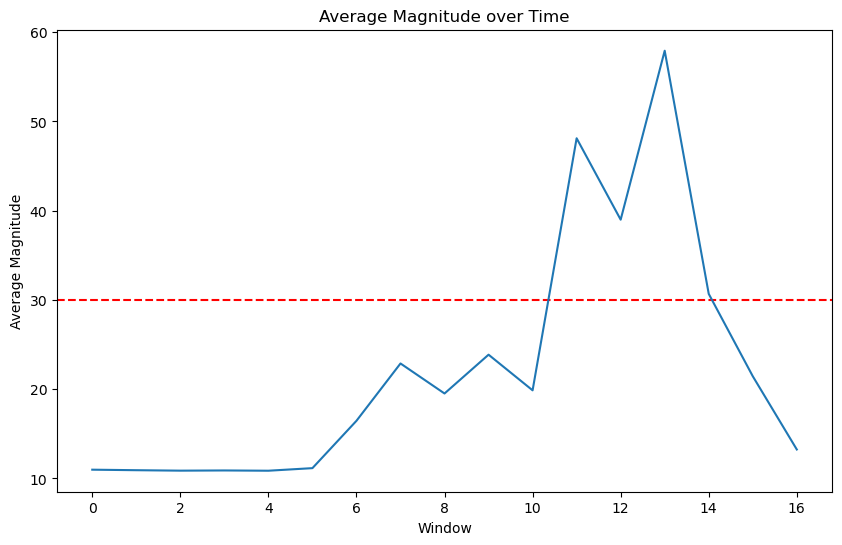

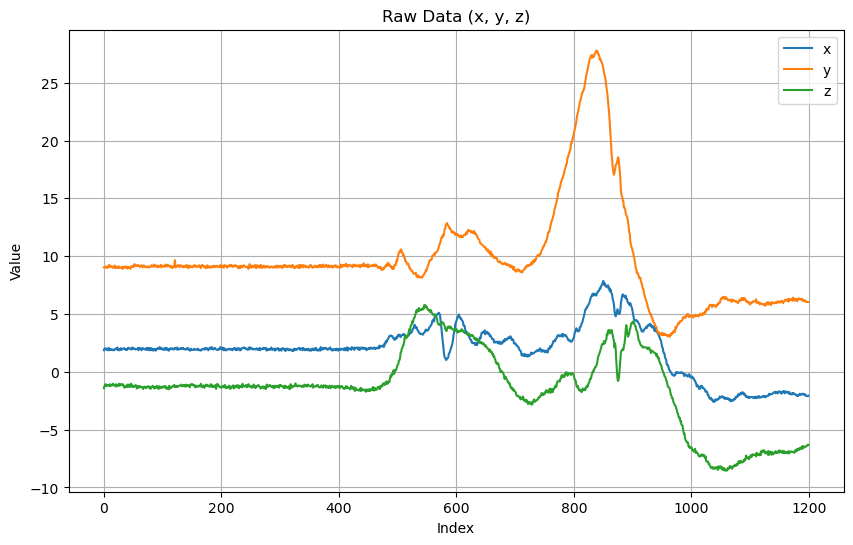

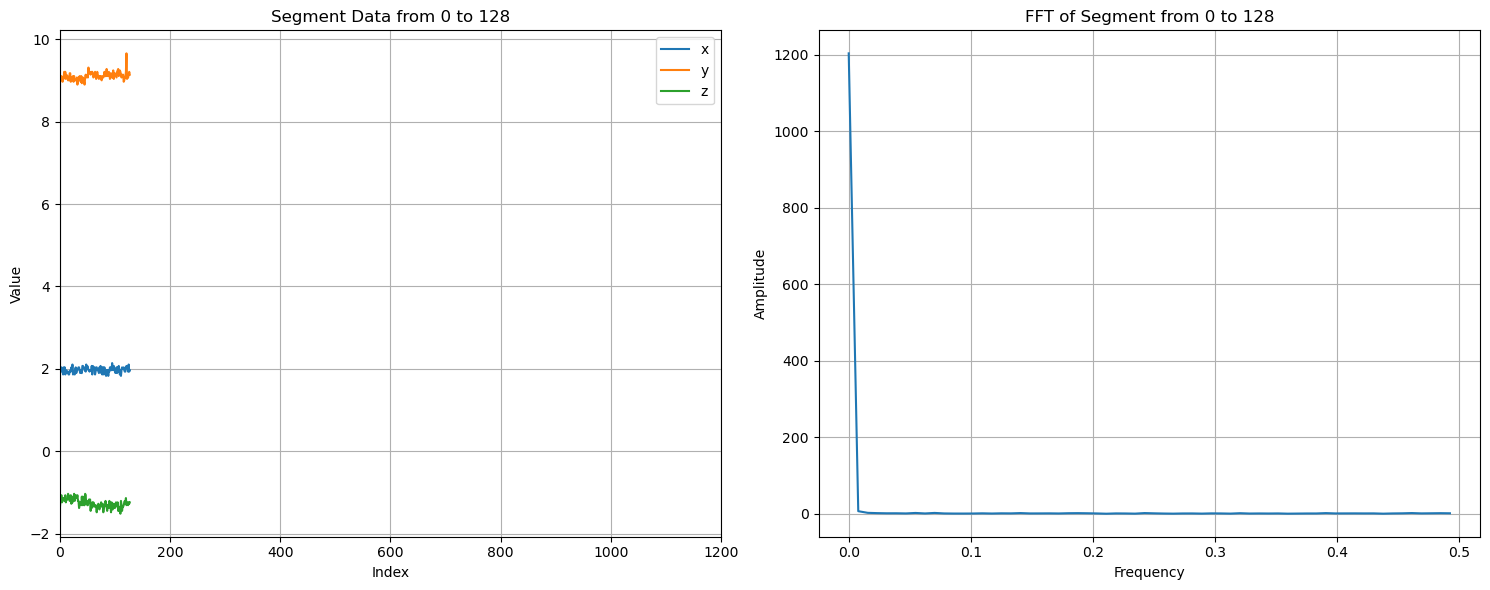

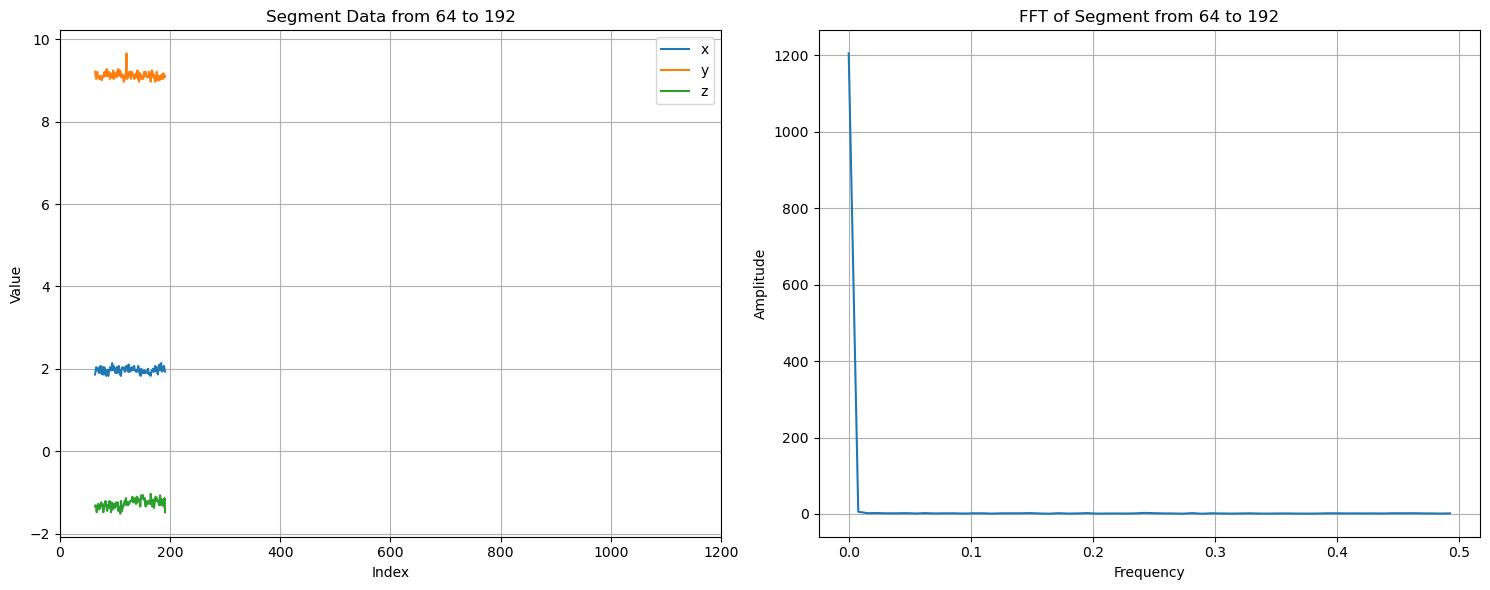

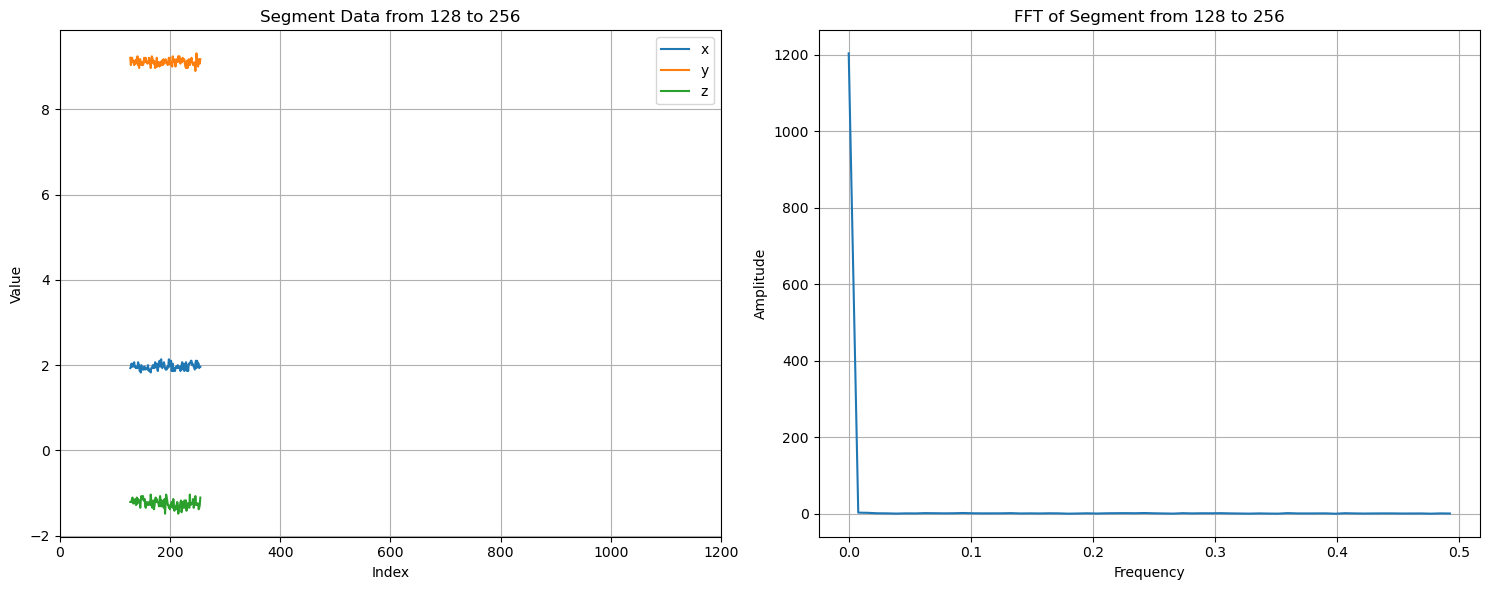

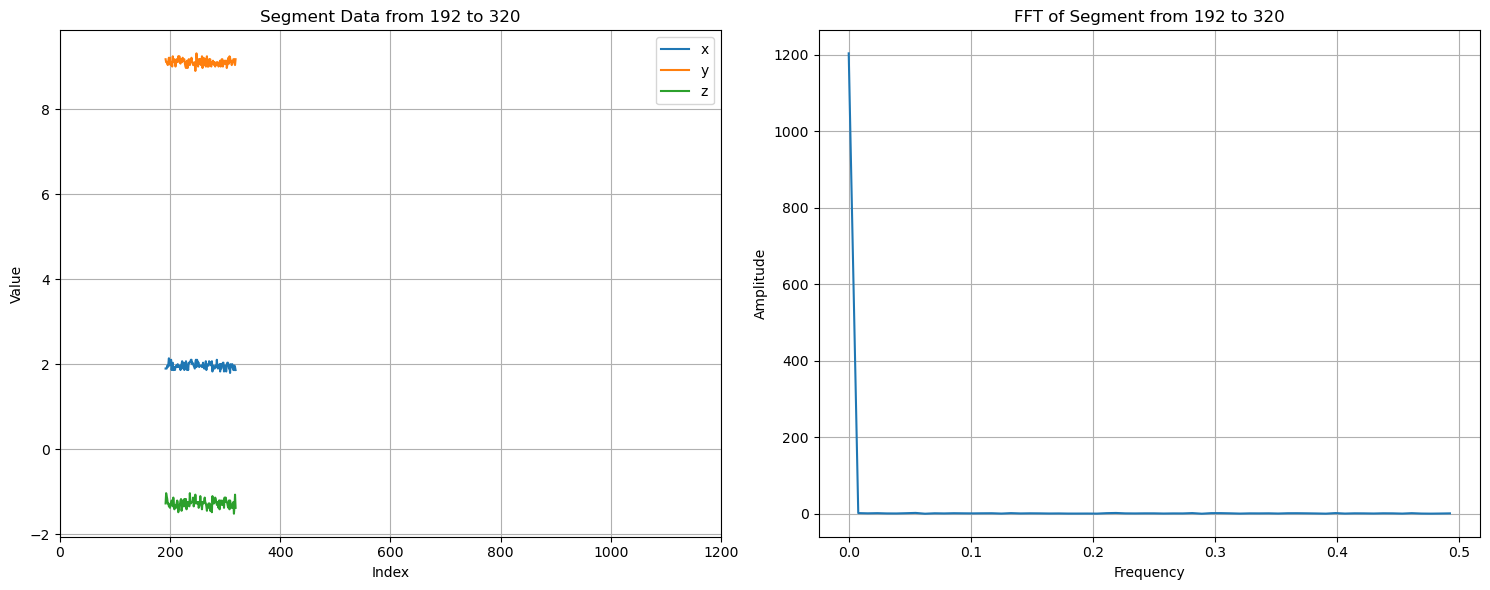

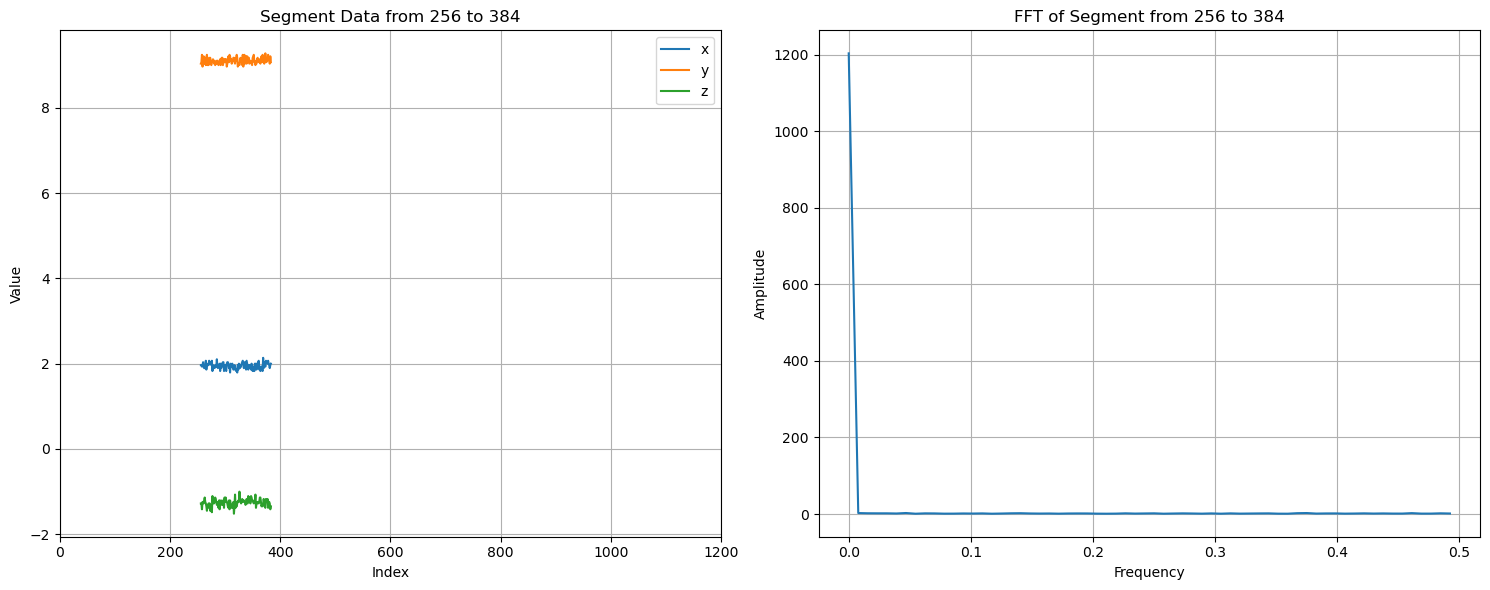

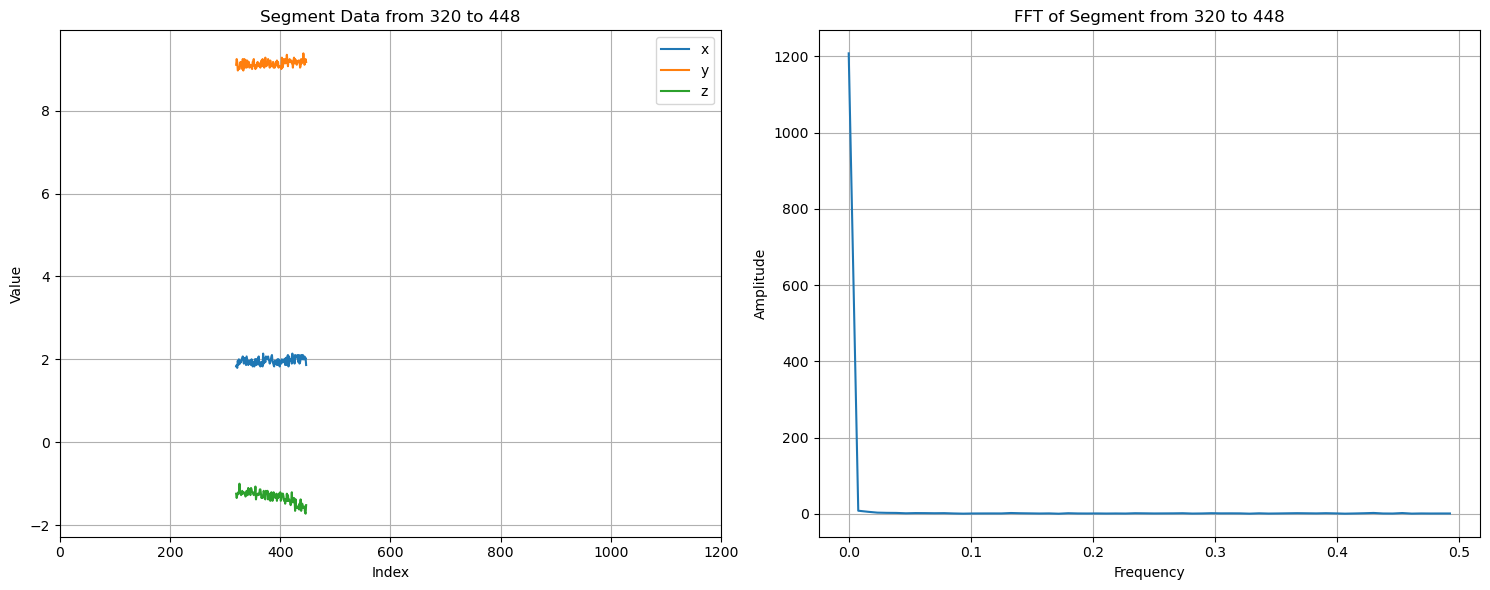

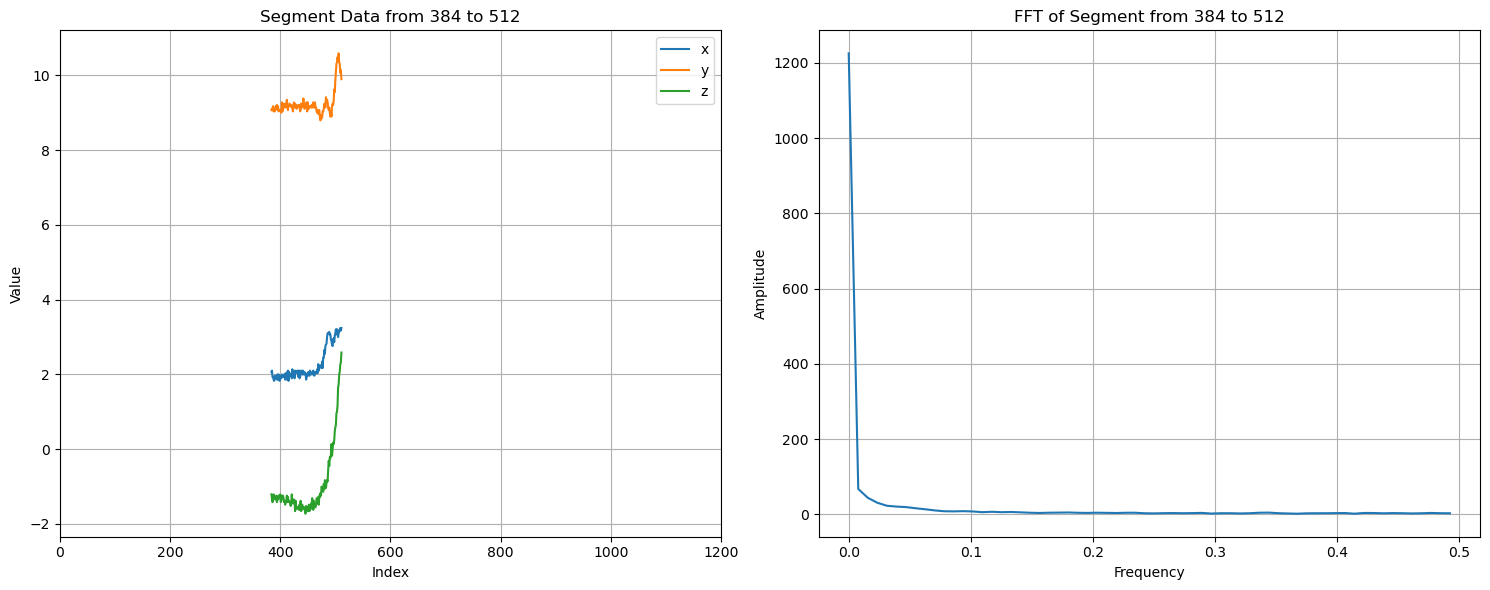

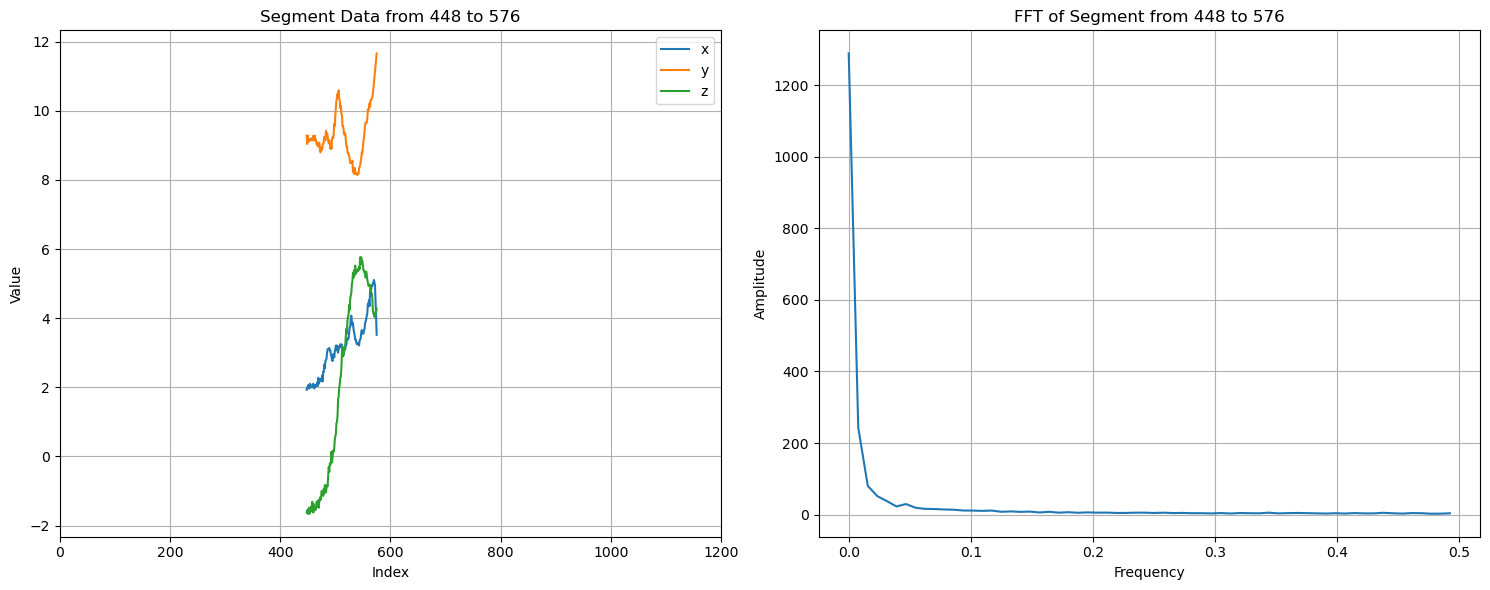

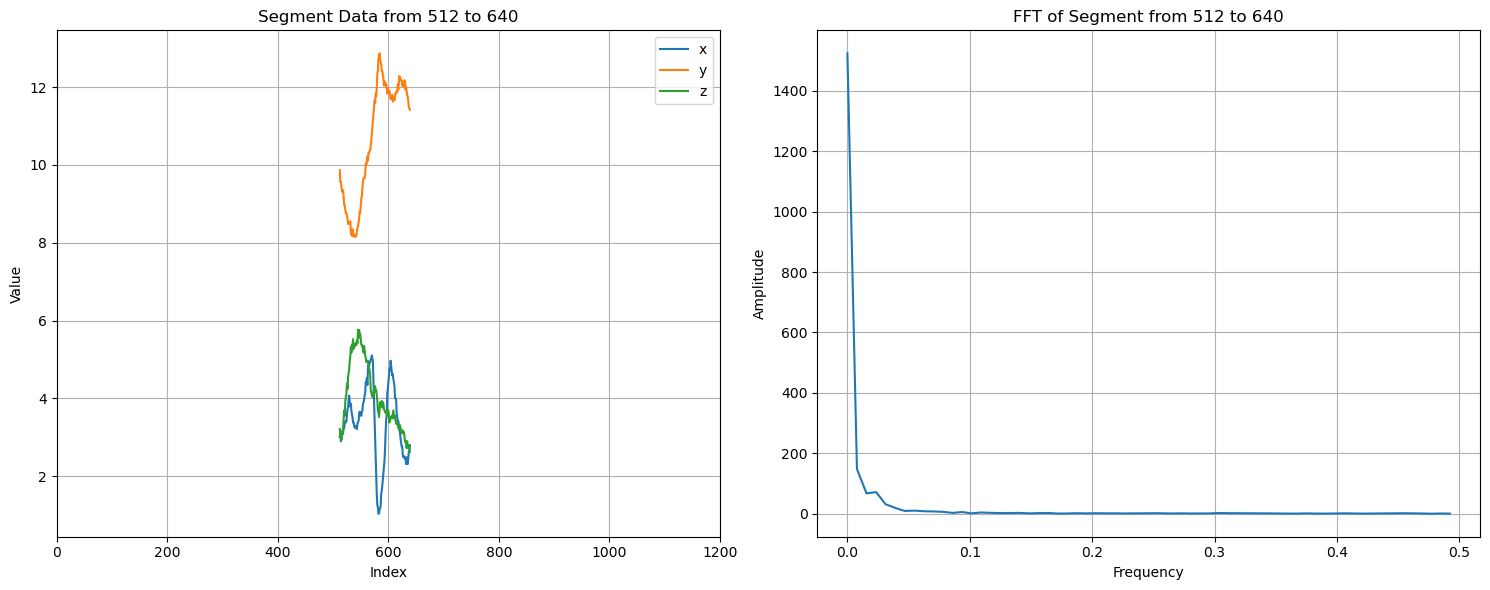

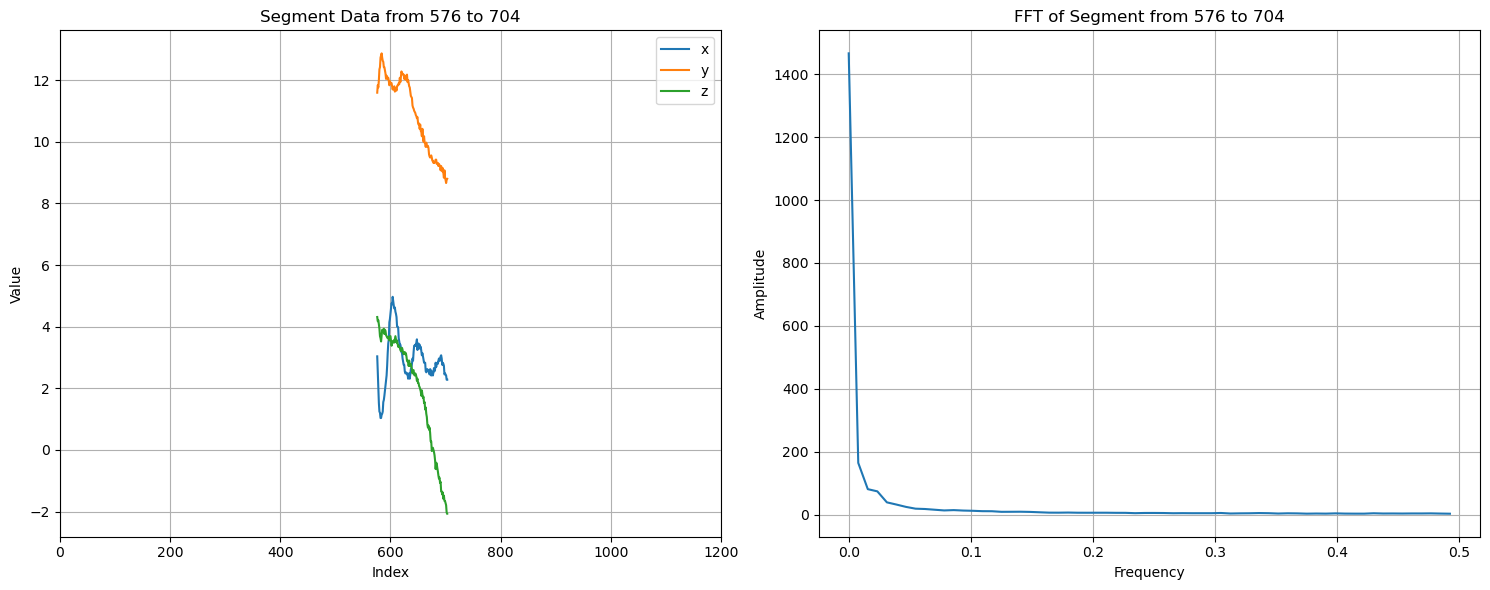

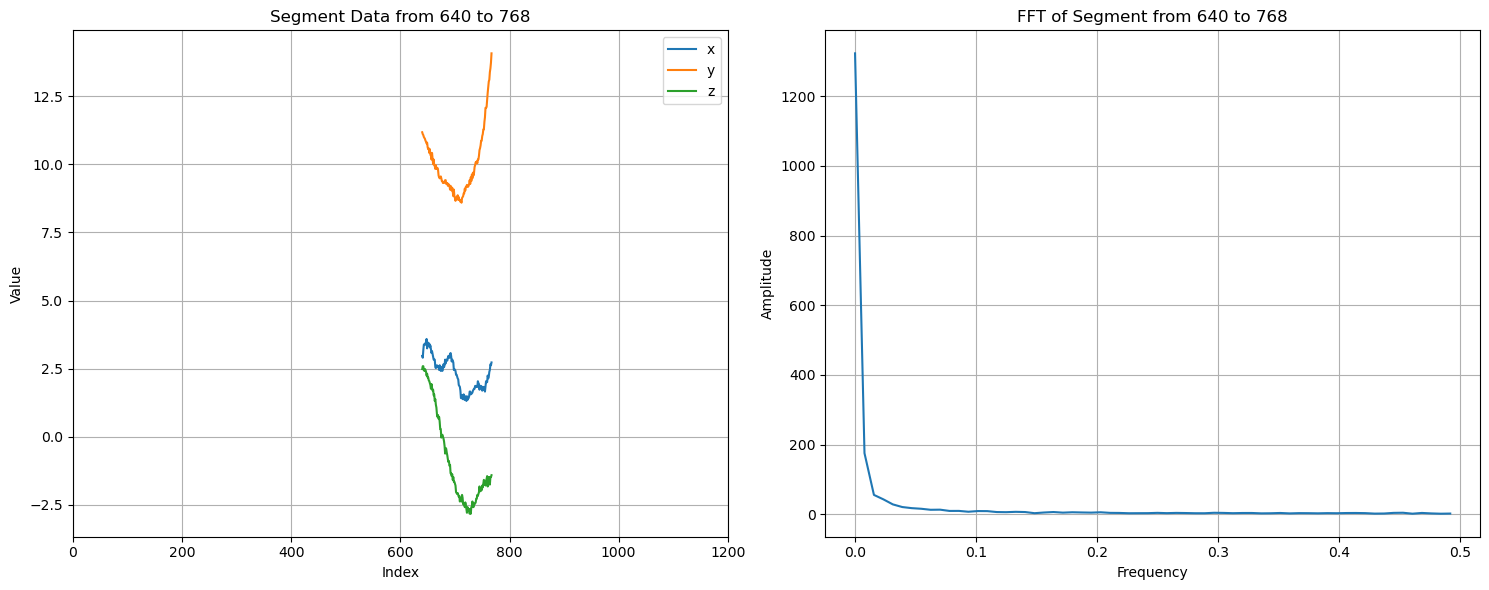

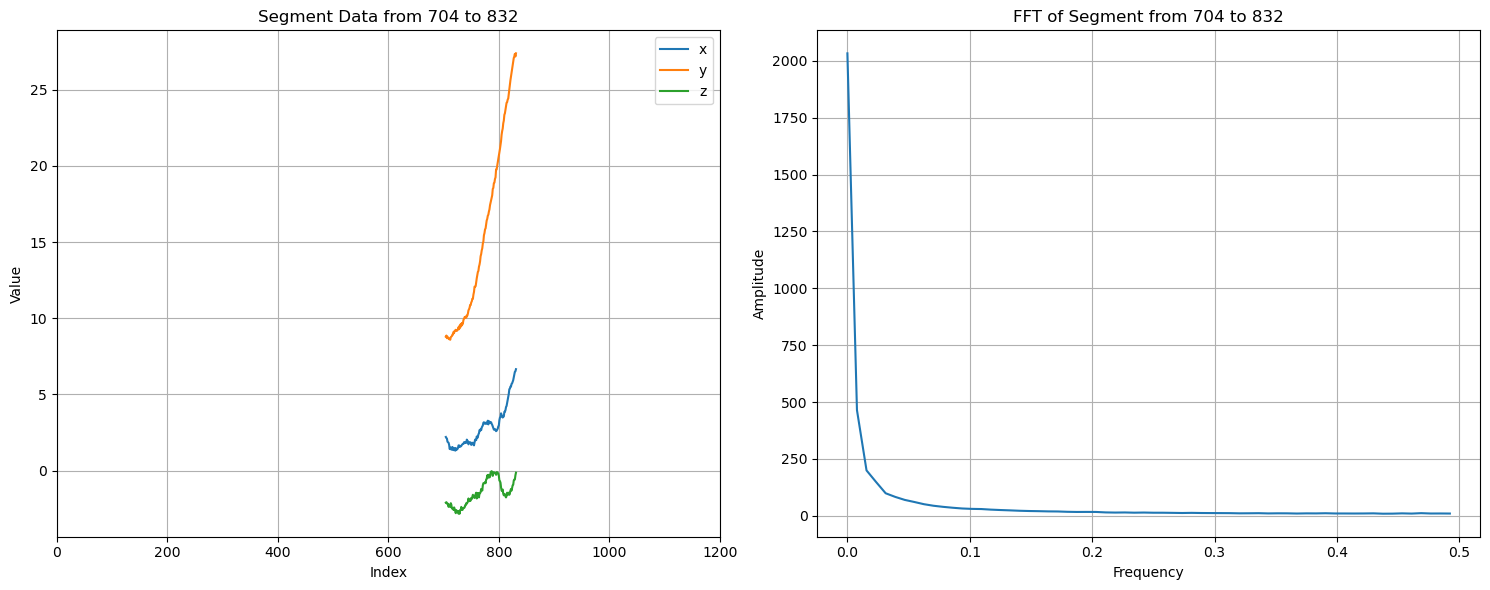

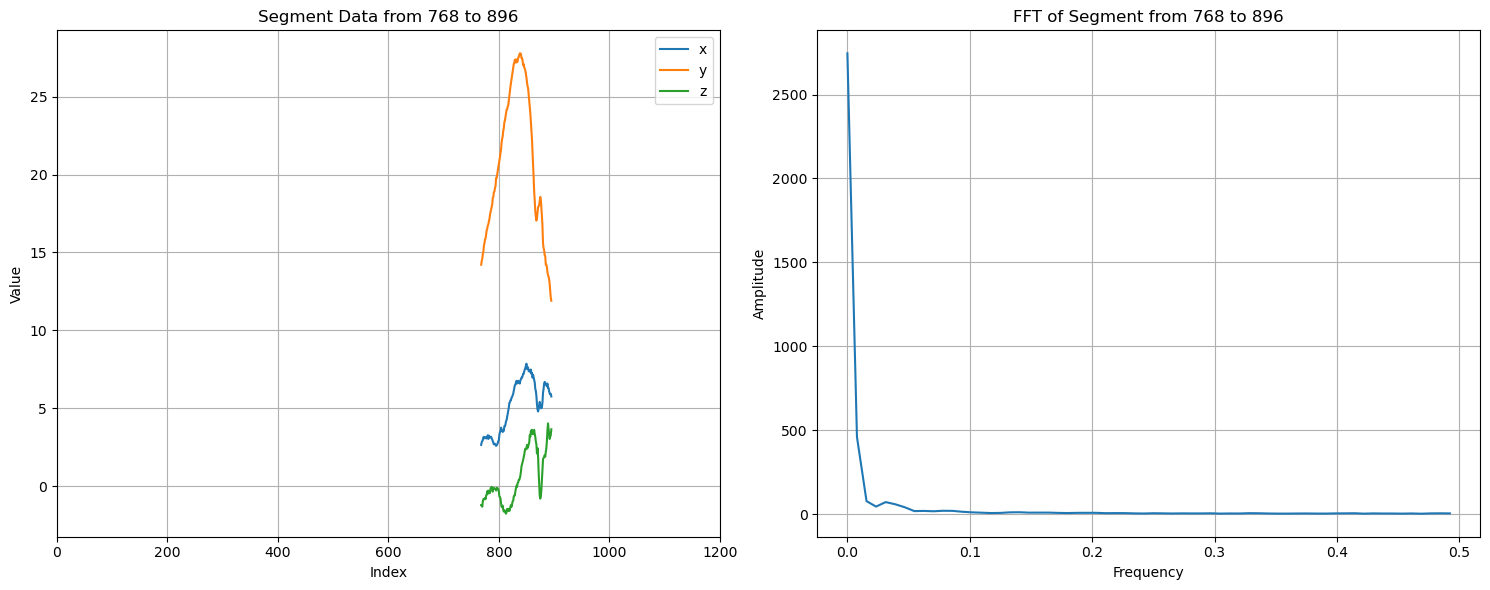

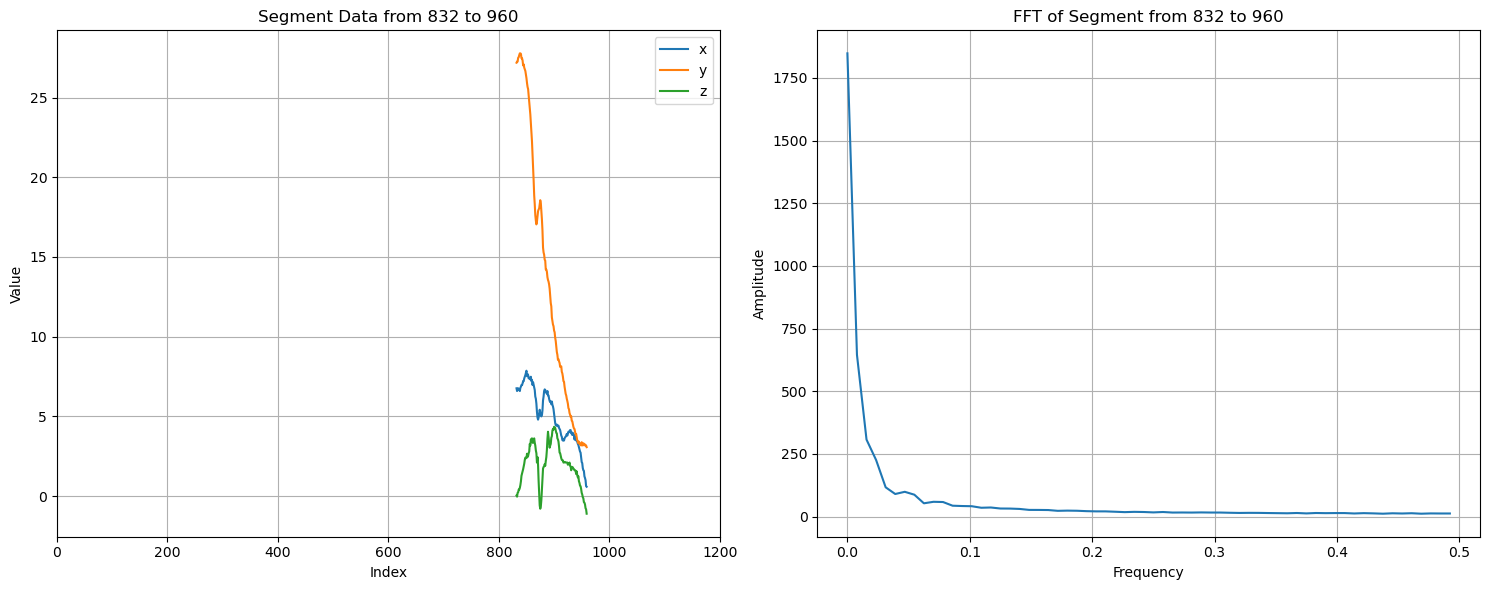

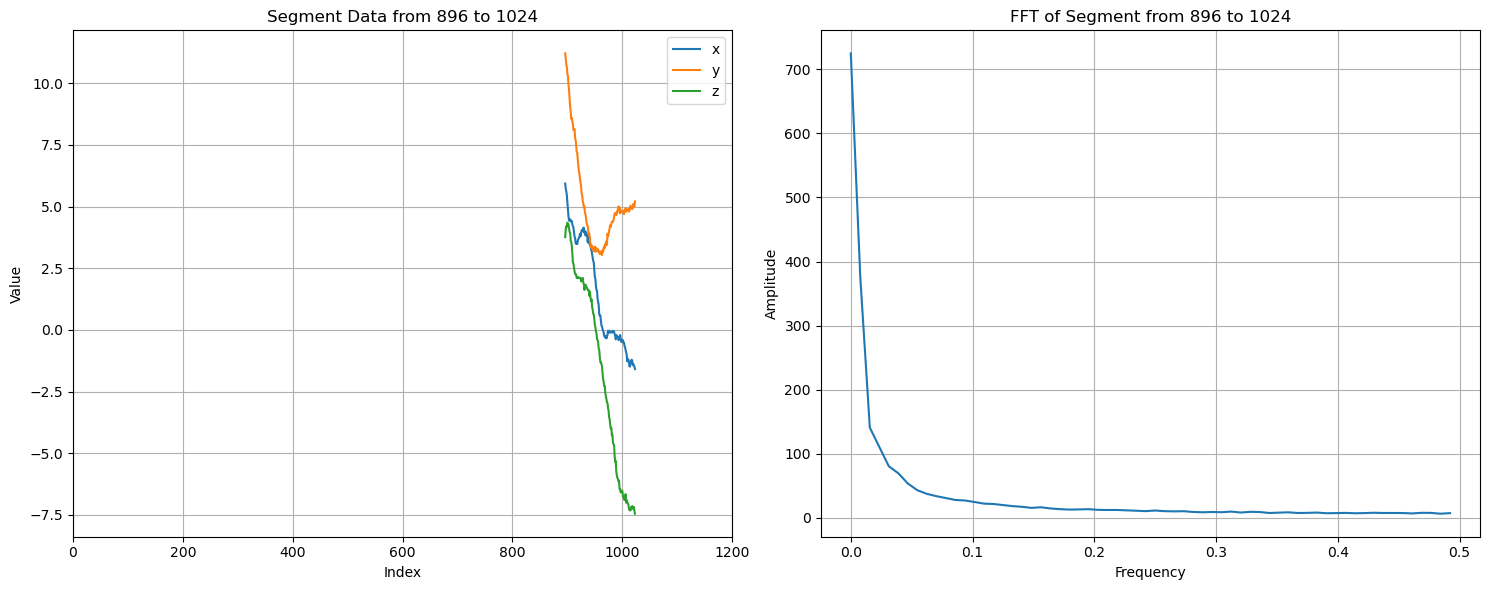

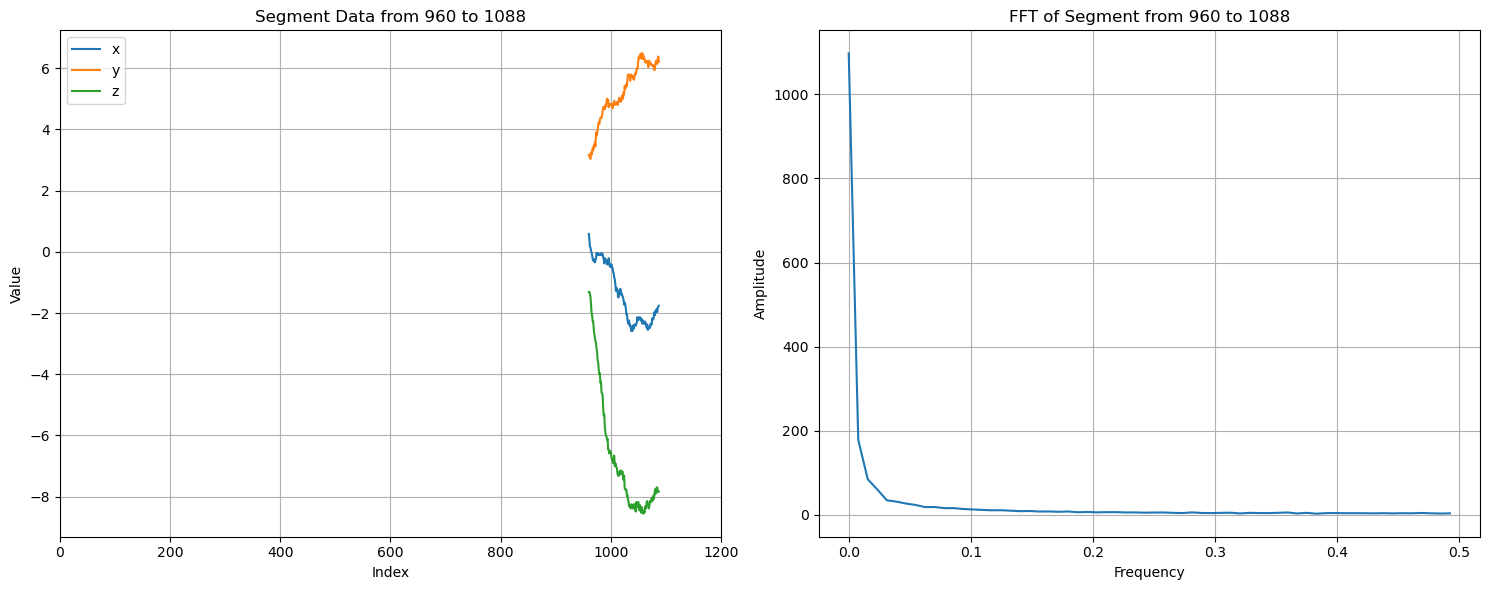

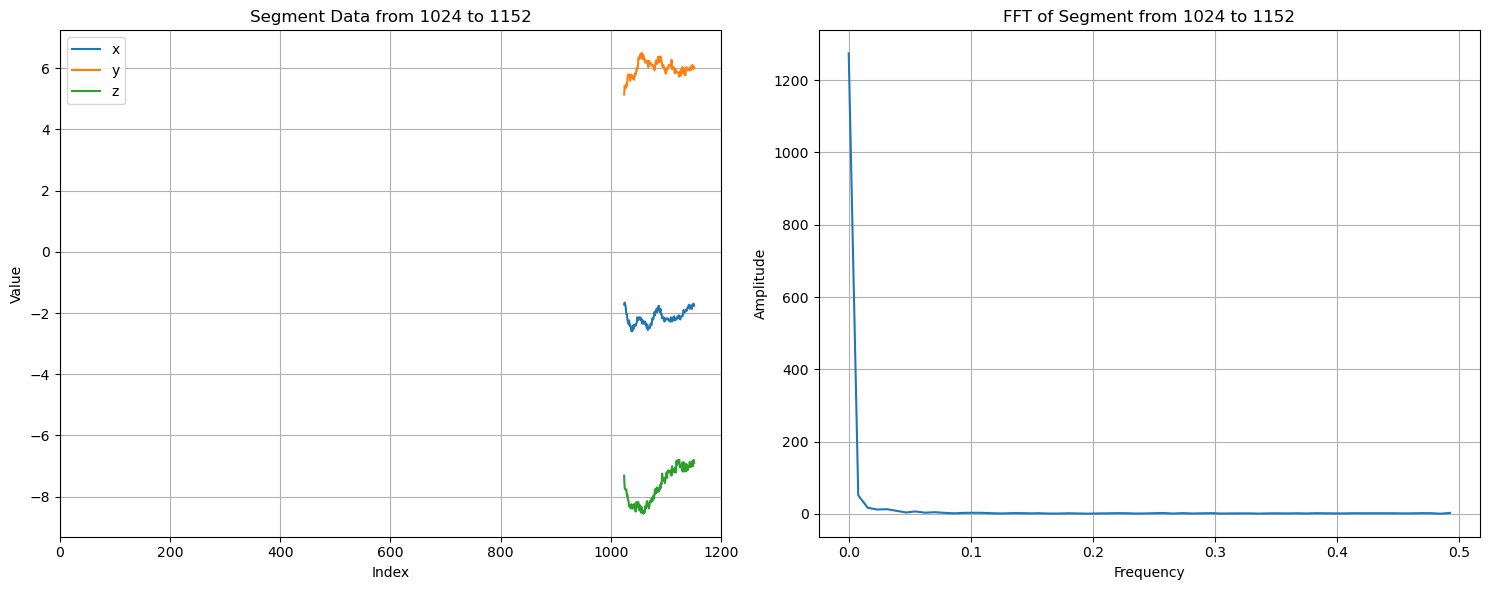

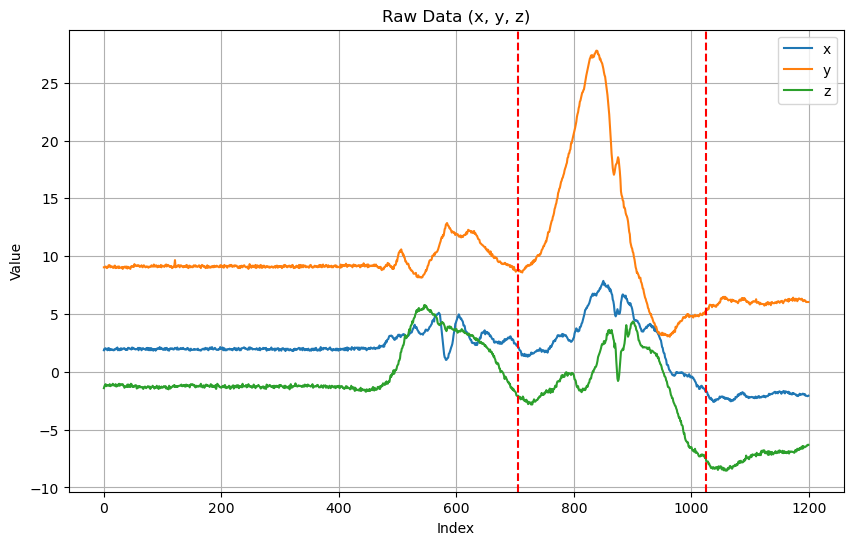

Fast movements detected in the following intervals: 704-832; 768-896; 832-960; 896-1024


In [33]:
# Compute average amplitudes and plot results
compute_average_magnitude_and_plot(real_df, window_size, step_size, threshold)